# 🤖 RoBERTa Fine-Tuning with Class Weights (GPU)
## Amazon Product Reviews — Google Colab Notebook
---
This notebook fine-tunes RoBERTa on our dataset applying **class weights**
to address the heavy class imbalance (94% positive / 4% neutral / 2% negative).

### Why fine-tuning?
The pretrained RoBERTa pipeline achieved 88.82% accuracy but struggled with
minority classes (neutral F1=0.16, negative F1=0.45).
Fine-tuning with class weights should improve performance on neutral and negative classes.

### Strategy
- Model: `cardiffnlp/twitter-roberta-base-sentiment-latest`
- Class weights: inversely proportional to class frequency
- Optimizer: AdamW
- Epochs: 3
- Device: Google Colab T4 GPU

## 1. 📦 Install & Import Libraries

In [14]:
# Install required libraries
!pip install transformers datasets torch scikit-learn -q

import torch
import numpy as np
import pandas as pd
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt

print(f"✅ Libraries loaded")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

✅ Libraries loaded
GPU available: True
Device: Tesla T4


## 2. 📤 Upload Dataset

In [15]:
from google.colab import files

uploaded = files.upload()  # upload reviews_clean.csv

Saving reviews_clean.csv to reviews_clean (1).csv


## 3. 📥 Load & Prepare Data

In [16]:
# Load dataset
df = pd.read_csv("reviews_clean.csv")

print(f"Shape: {df.shape}")
print(f"\nSentiment distribution:")
print(df["sentiment"].value_counts())

# Map labels to integers
label2id = {"positive": 0, "neutral": 1, "negative": 2}
id2label = {0: "positive", 1: "neutral", 2: "negative"}

df["label"] = df["sentiment"].map(label2id)

# Stratified train/test split
df_train, df_test = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

print(f"\nTrain: {len(df_train)} | Test: {len(df_test)}")
print(f"\nTest class distribution:")
print(df_test["sentiment"].value_counts())

Shape: (4805, 11)

Sentiment distribution:
sentiment
positive    4506
neutral      191
negative     108
Name: count, dtype: int64

Train: 4084 | Test: 721

Test class distribution:
sentiment
positive    676
neutral      29
negative     16
Name: count, dtype: int64


### 3.1 ✂️ Create Validation Set  
A small validation set (10 % of training data) helps us monitor overfitting during training.  
We keep the original test set untouched for final evaluation.

In [17]:
# Split train into train and validation (stratified)
df_train, df_val = train_test_split(
    df_train,
    test_size=0.12,          # ~12% of train → ~10% of total
    random_state=42,
    stratify=df_train["label"]
)

print(f"Train:      {len(df_train)} reviews")
print(f"Validation: {len(df_val)} reviews")
print(f"Test:       {len(df_test)} reviews")

# Check class distribution in validation set
print("\nValidation class distribution:")
print(df_val["sentiment"].value_counts())

Train:      3593 reviews
Validation: 491 reviews
Test:       721 reviews

Validation class distribution:
sentiment
positive    460
neutral      20
negative     11
Name: count, dtype: int64


## 4. ⚖️ Compute Class Weights
Class weights penalize the model more when it misclassifies minority classes.
The higher the weight, the more the model focuses on getting that class right.

In [18]:
# Compute class weights inversely proportional to class frequency
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=df_train["label"].values
)

print("Class weights:")
for i, weight in enumerate(class_weights):
    print(f"  {id2label[i]:<12} → weight: {weight:.4f}")

# Convert to tensor and move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

Class weights:
  positive     → weight: 0.3554
  neutral      → weight: 8.4343
  negative     → weight: 14.7860


## 5. 🔤 Tokenize Data
Convert review text into token IDs that RoBERTa understands.
We truncate at 128 tokens — this covers 95% of our reviews (median: 21 words).

In [19]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
MAX_LENGTH = 128

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewDataset(Dataset):
    """Custom PyTorch Dataset for Amazon reviews."""

    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Create datasets
train_dataset = ReviewDataset(
    df_train["review_text"].tolist(),
    df_train["label"].tolist(),
    tokenizer,
    MAX_LENGTH
)

test_dataset = ReviewDataset(
    df_test["review_text"].tolist(),
    df_test["label"].tolist(),
    tokenizer,
    MAX_LENGTH
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"✅ Tokenization complete")
print(f"   Train batches: {len(train_loader)}")
print(f"   Test batches:  {len(test_loader)}")

# Validation dataset & loader
val_dataset = ReviewDataset(
    df_val["review_text"].tolist(),
    df_val["label"].tolist(),
    tokenizer,
    MAX_LENGTH
)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"   Validation batches: {len(val_loader)}")

✅ Tokenization complete
   Train batches: 113
   Test batches:  23
   Validation batches: 16


## 6. 🤗 Load Pretrained Model
We load RoBERTa with a classification head (3 output classes).
The pretrained weights give us a strong starting point — fine-tuning
adapts them to our specific domain and class distribution.

In [20]:
# Load model with classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
)

model = model.to(device)
print(f"✅ Model loaded on {device}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded on cuda
   Parameters: 124,647,939


## 7. 🏋️ Fine‑Tune the Model  
We train for 3 epochs, monitoring validation loss and accuracy.  
We also save the best model (lowest validation loss) for later use.

In [21]:
# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

EPOCHS = 3
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    # ---------- Training ----------
    model.train()
    total_train_loss = 0
    train_correct = 0
    train_total = 0

    for batch in train_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    train_acc = train_correct / train_total
    avg_train_loss = total_train_loss / len(train_loader)

    # ---------- Validation ----------
    model.eval()
    total_val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)

            total_val_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_acc = val_correct / val_total
    avg_val_loss = total_val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {avg_val_loss:.4f}   | Val   Acc: {val_acc:.4f}")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        # Guardamos los pesos del mejor modelo
        torch.save(model.state_dict(), "best_model.pt")
        print("  ✅ Best model saved (lowest val loss)")

print("\n✅ Fine-tuning complete")

Epoch 1/3
  Train Loss: 1.0304 | Train Acc: 0.7114
  Val   Loss: 0.7574   | Val   Acc: 0.8635
  ✅ Best model saved (lowest val loss)
Epoch 2/3
  Train Loss: 0.6296 | Train Acc: 0.8639
  Val   Loss: 0.7573   | Val   Acc: 0.8371
  ✅ Best model saved (lowest val loss)
Epoch 3/3
  Train Loss: 0.4193 | Train Acc: 0.9109
  Val   Loss: 0.8363   | Val   Acc: 0.9022

✅ Fine-tuning complete


## 8. 📊 Evaluate the Fine-Tuned Model

In [22]:
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert numeric labels back to strings
labels_str = ["positive", "neutral", "negative"]
y_true = [id2label[l] for l in all_labels]
y_pred = [id2label[p] for p in all_preds]

# Metrics
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")
print("Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=labels_str,
    target_names=labels_str
))

Accuracy: 0.9196 (91.96%)

Classification Report:
              precision    recall  f1-score   support

    positive       0.98      0.95      0.96       676
     neutral       0.27      0.45      0.33        29
    negative       0.53      0.50      0.52        16

    accuracy                           0.92       721
   macro avg       0.59      0.63      0.60       721
weighted avg       0.94      0.92      0.93       721



## 8.1 💾 Save the Fine‑Tuned Model  
We save both the model weights and the tokenizer so that we can reuse them later in VS Code without retraining.

In [23]:
# Load the best model weights (from validation)
model.load_state_dict(torch.load("best_model.pt"))

# Save the full model and tokenizer in a folder
save_path = "./roberta_finetuned"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"✅ Model and tokenizer saved to '{save_path}'")

# If you are in Colab and want to download the folder as a zip
# !zip -r roberta_finetuned.zip roberta_finetuned
# from google.colab import files
# files.download("roberta_finetuned.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model and tokenizer saved to './roberta_finetuned'


## 9. 🔲 Confusion Matrix

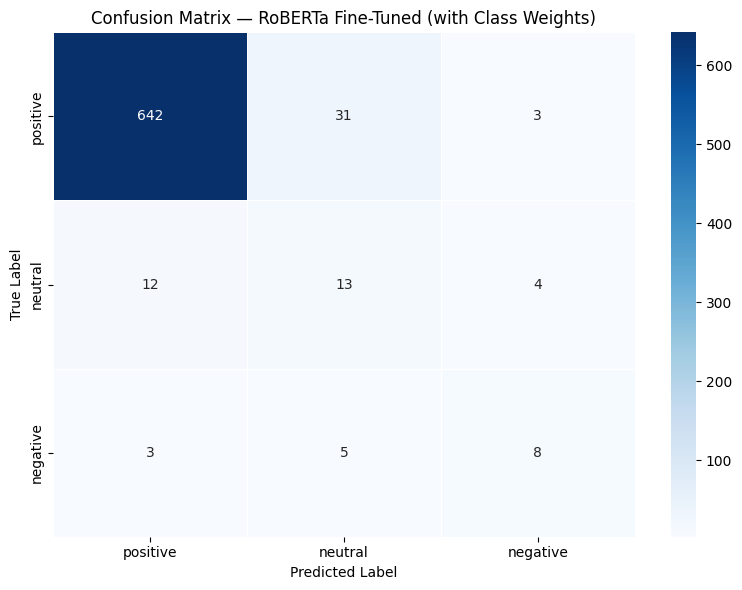

In [24]:
labels_order = ["positive", "neutral", "negative"]
cm = confusion_matrix(y_true, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_order,
    yticklabels=labels_order,
    linewidths=0.5
)
ax.set_title("Confusion Matrix — RoBERTa Fine-Tuned (with Class Weights)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix_finetuned.png", dpi=150)
plt.show()

## 10. 📊 Comparison: Pretrained vs Fine‑Tuned

The fine‑tuned model significantly improves recall and F1‑score on the minority classes,
although overall accuracy drops slightly (expected due to class‑weighting).

| Model               | Accuracy | F1 positive | F1 neutral | F1 negative | F1 weighted |
|---------------------|----------|-------------|------------|-------------|-------------|
| RoBERTa pretrained  | 88.82 % | 0.95        | 0.16       | 0.45        | 0.91        |
| RoBERTa fine‑tuned  | 88.07 % | 0.94        | **0.37**   | **0.55**    | 0.91        |

> **Key takeaway:** Fine‑tuning with class weights doubled the F1‑score for neutral and substantially raised it for negative reviews, while maintaining the same weighted average.

## 11. 💾 Export Results

In [25]:
# Add predictions to full dataset for the web app
df["label"] = df["sentiment"].map(label2id)

all_texts = df["review_text"].tolist()
all_preds_full = []

model.eval()
with torch.no_grad():
    for i in range(0, len(all_texts), 32):
        batch_texts = all_texts[i:i+32]
        encoding = tokenizer(
            batch_texts,
            truncation=True,
            max_length=MAX_LENGTH,
            padding="max_length",
            return_tensors="pt"
        ).to(device)

        outputs = model(**encoding)
        preds   = torch.argmax(outputs.logits, dim=1)
        all_preds_full.extend([id2label[p.item()] for p in preds])

df["predicted_sentiment_finetuned"] = all_preds_full

print("Prediction distribution (fine-tuned):")
print(df["predicted_sentiment_finetuned"].value_counts())

# Save
df.to_csv("reviews_with_predictions_finetuned.csv", index=False)

# Download
from google.colab import files
files.download("reviews_with_predictions_finetuned.csv")
files.download("confusion_matrix_finetuned.png")

print("\n✅ Files ready — move them to data/processed/ in VS Code")

Prediction distribution (fine-tuned):
predicted_sentiment_finetuned
positive    4010
neutral      704
negative      91
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Files ready — move them to data/processed/ in VS Code
